# PubMed RCT Classification - EDA

Exploratory Data Analysis for Medical Text Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings("ignore")

In [2]:
LABEL2ID = {
    "BACKGROUND": 0,
    "OBJECTIVE": 1,
    "METHODS": 2,
    "RESULTS": 3,
    "CONCLUSIONS": 4,
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

In [3]:
train_df = pd.read_csv("../data/train.csv")
val_df = pd.read_csv("../data/val.csv")
test_df = pd.read_csv("../data/test.csv")

# Ensure text column is always string to avoid len()/split() errors on NaN/float values
for df in (train_df, val_df, test_df):
    df["sentence"] = df["sentence"].fillna("").astype(str)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 39967, Val: 5015, Test: 5018


## 1. Label Distribution

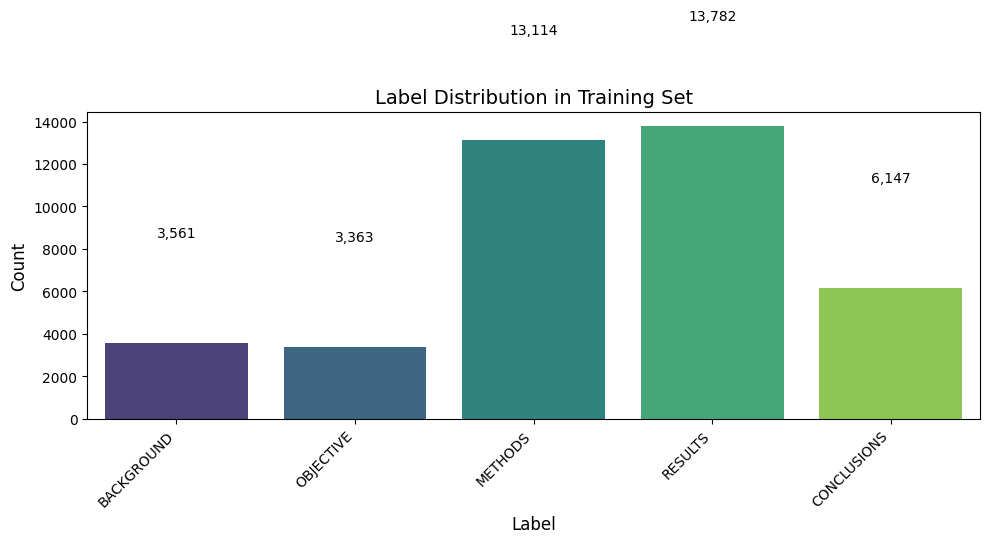

In [4]:
plt.figure(figsize=(10, 6))
label_counts = train_df["label"].value_counts().sort_index()
labels = [ID2LABEL[i] for i in label_counts.index]

sns.barplot(x=labels, y=label_counts.values, palette="viridis")
plt.title("Label Distribution in Training Set", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(label_counts.values):
    plt.text(i, v + 5000, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../results/label_distribution.png", dpi=150)
plt.show()

In [5]:
print("\nLabel Distribution (%):")
for i, label in ID2LABEL.items():
    count = (train_df["label"] == i).sum()
    pct = 100 * count / len(train_df)
    print(f"  {label:15s}: {count:>8,} ({pct:.2f}%)")


Label Distribution (%):
  BACKGROUND     :    3,561 (8.91%)
  OBJECTIVE      :    3,363 (8.41%)
  METHODS        :   13,114 (32.81%)
  RESULTS        :   13,782 (34.48%)
  CONCLUSIONS    :    6,147 (15.38%)


## 2. Sentence Length Analysis

In [6]:
train_df["sentence_length"] = train_df["sentence"].apply(len)
train_df["word_count"] = train_df["sentence"].apply(lambda x: len(x.split()))

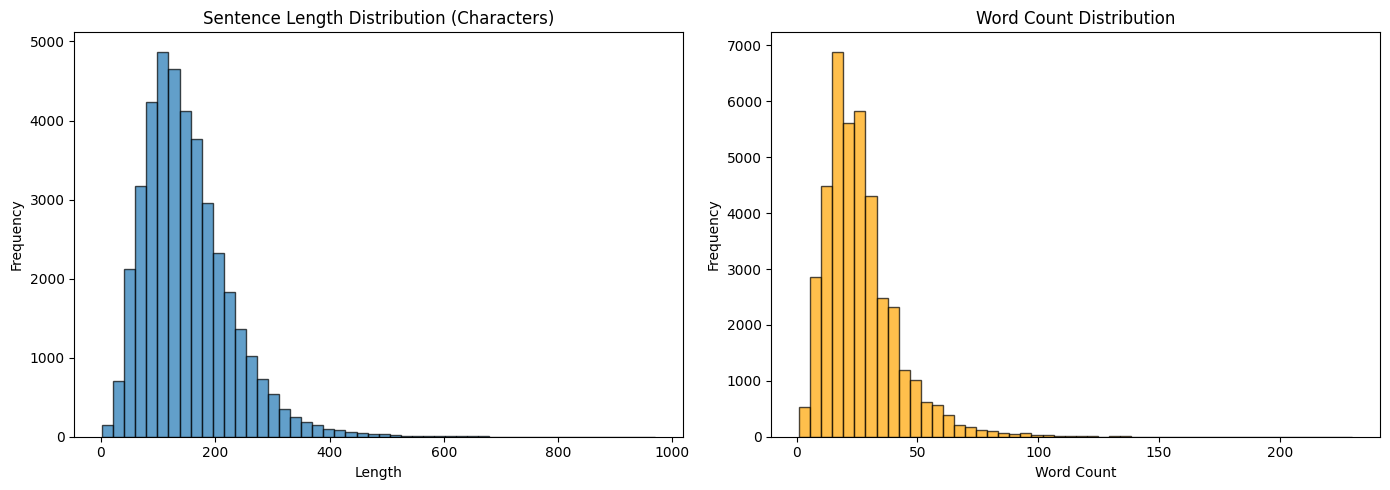

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df["sentence_length"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Sentence Length Distribution (Characters)", fontsize=12)
axes[0].set_xlabel("Length")
axes[0].set_ylabel("Frequency")

axes[1].hist(
    train_df["word_count"], bins=50, edgecolor="black", alpha=0.7, color="orange"
)
axes[1].set_title("Word Count Distribution", fontsize=12)
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("../results/length_distribution.png", dpi=150)
plt.show()

In [8]:
print("Sentence Length Statistics:")
print(train_df[["sentence_length", "word_count"]].describe())

Sentence Length Statistics:
       sentence_length    word_count
count     39967.000000  39967.000000
mean        150.941852     26.273651
std          76.854592     15.053035
min           2.000000      1.000000
25%          97.000000     16.000000
50%         138.000000     23.000000
75%         190.000000     33.000000
max         970.000000    230.000000


## 3. Sentence Length by Label

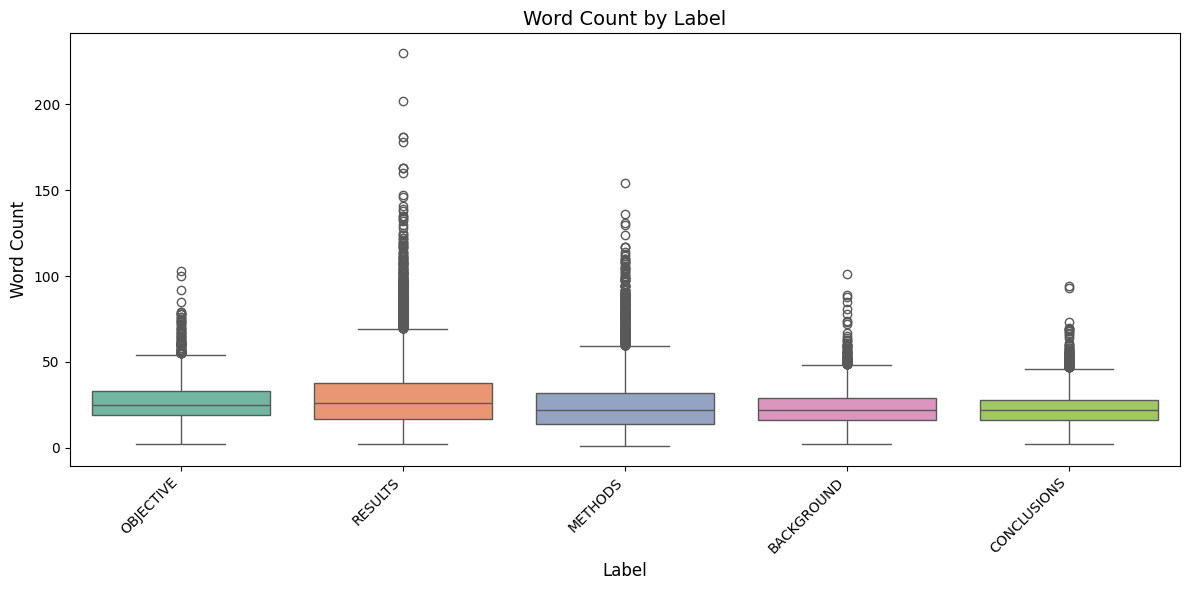

In [9]:
plt.figure(figsize=(12, 6))
train_df["label_name"] = train_df["label"].map(ID2LABEL)
sns.boxplot(data=train_df, x="label_name", y="word_count", palette="Set2")
plt.title("Word Count by Label", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Word Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../results/word_count_by_label.png", dpi=150)
plt.show()

In [10]:
print("\nMean Word Count by Label:")
for label in LABEL2ID.keys():
    mean_wc = train_df[train_df["label_name"] == label]["word_count"].mean()
    std_wc = train_df[train_df["label_name"] == label]["word_count"].std()
    print(f"  {label:15s}: {mean_wc:.1f} ± {std_wc:.1f}")


Mean Word Count by Label:
  BACKGROUND     : 23.1 ± 11.0
  OBJECTIVE      : 27.2 ± 11.4
  METHODS        : 24.9 ± 15.2
  RESULTS        : 29.6 ± 17.7
  CONCLUSIONS    : 22.9 ± 9.4


## 4. Sample Sentences by Label

In [11]:
for label in LABEL2ID.keys():
    print(f"\n=== {label} ===")
    samples = train_df[train_df["label_name"] == label]["sentence"].head(2).values
    for s in samples:
        print(f"  - {s[:150]}...")


=== BACKGROUND ===
  - However , the clinical competency of newly qualified nurses continues to stimulate debate about the adequacy of current methods of clinical skills edu...
  - Many patients continue to take regular beta agonists , often at high doses , contrary to national and international guidelines ....

=== OBJECTIVE ===
  - This randomized , double-blind , multicenter study was conducted to confirm a previous finding that lansoprazole relieves heartburn faster than omepra...
  - The efficacy and safety of cetirizine 10 mg qd , terfenadine 60 mg bid , and placebo were compared in patients with seasonal allergic rhinitis ....

=== METHODS ===
  - Healthy male volunteers ( n = 26 , age 19-53 years ) randomly received a single sublingual dose of asenapine 5 mg after 10 h fasting ( Treatment A , r...
  - Injections were given under imaging control ....

=== RESULTS ===
  - Twenty-one patients ( 16 , 6 % ) had respiratory depression [ hypercarbia ( ETco2 > 50 mm Hg ) or hypoxia ( 

## 5. Unique Abstracts Analysis

In [12]:
print(f"Unique abstracts in train: {train_df['abstract_id'].nunique()}")
print(f"Unique abstracts in val: {val_df['abstract_id'].nunique()}")
print(f"Unique abstracts in test: {test_df['abstract_id'].nunique()}")

sentences_per_abstract = train_df.groupby("abstract_id").size()
print(
    f"\nSentences per abstract: mean={sentences_per_abstract.mean():.1f}, max={sentences_per_abstract.max()}, min={sentences_per_abstract.min()}"
)

Unique abstracts in train: 35274
Unique abstracts in val: 4409
Unique abstracts in test: 4410

Sentences per abstract: mean=1.1, max=4, min=1


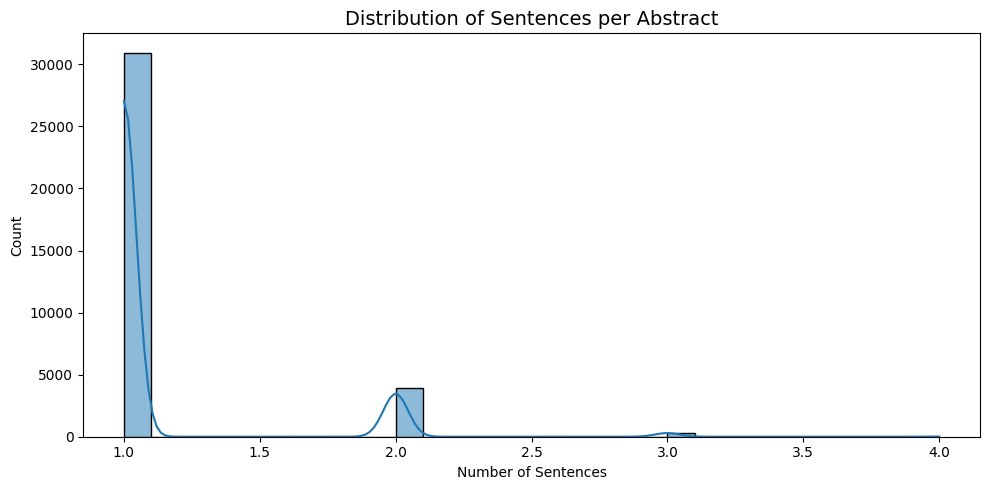

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(sentences_per_abstract, bins=30, kde=True)
plt.title("Distribution of Sentences per Abstract", fontsize=14)
plt.xlabel("Number of Sentences")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../results/sentences_per_abstract.png", dpi=150)
plt.show()